This notebook contains training a neural network for additional current with which we try to match the recording from a MULTI-compartment ACTIVE model to our real, experimental data.

Here we use the normalized voltage and the us as input to the neural network (time is not included!). We define u in a differential equation.

We initialize the NN based on https://arxiv.org/pdf/2311.15890, and with it we get stable u values.

For the best results we use two separate NNs for the spiking and non-spiking regions.

After the first training (dtw loss with some spike-height punishment) we choose the best 40 models to fine-tune (sse loss).

Multi-compartment fitting is really computationally heavy, so I rather trained on the cluster with scripts in the scripts folder.

In [ ]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)


import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import jaxley as jx


import jax.random as jr
from typing import List


import equinox as eqx
import flax.nnx as nnx

from voltage_fitting.posthoc_summary_stats import (
    find_spikes,
    spike_count,
)

from voltage_fitting.loss_util import (
    get_scaled_loss,
)


dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


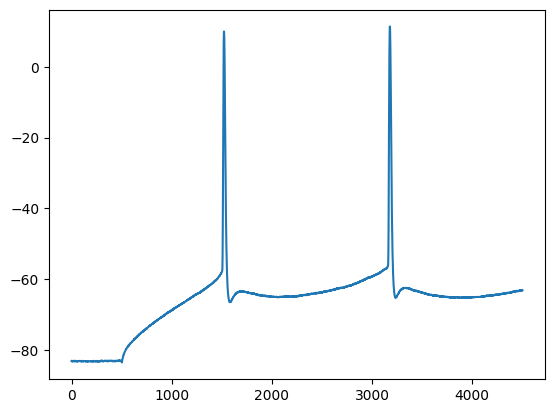

In [ ]:
t_max = 150
cut = 1500  # We cut the first 1500 datapoints because this period contains no stimulus

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"

# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data
)

t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

plt.plot(v_data[0])
np.save("results/v_data.npy", v_data)

In [3]:
# Define the multi-compartment cell to train
from voltage_fitting.build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [4]:
# Sampling parameters
names, lower, upper = get_bounds()


transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_multi = simulate(inv_sampled_params)

Number of parameters: 25


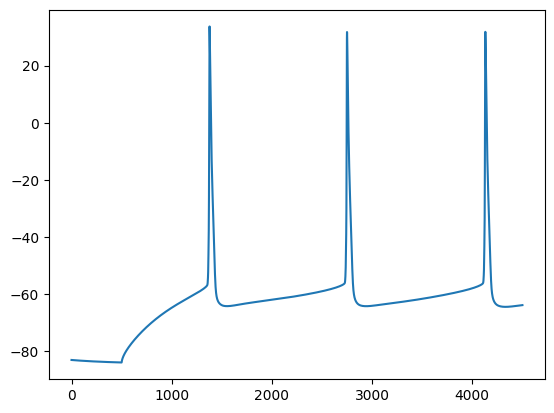

In [5]:
plt.plot(v_multi[0])

In [ ]:
# Initialization
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices,
)

key = jax.random.PRNGKey(0)
dt = 0.025
u_dimension = 8

eigs = rejection_sample_eigenvalues(
    key = key,
    solver_order=1,   
    h=dt,
    u_dim=u_dimension,
    use_complex=True,
)

num_layers = 3
layer_shapes = [(u_dimension + 1, 32), (32, 16), (16, u_dimension)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)

# Possible normalization functions
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)

# Define the neural network
class SimpleNeuralNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k_b1, k_b2, k_b3 = jr.split(key, 6)

        self.linear1 = eqx.nn.Linear(u_dimension + 1, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 16, key=k2)
        self.linear3 = eqx.nn.Linear(16, u_dimension, key=k3)


        self.linear1 = eqx.tree_at(lambda l: l.weight, self.linear1, W_matrices[0])
        self.linear2 = eqx.tree_at(lambda l: l.weight, self.linear2, W_matrices[1])
        self.linear3 = eqx.tree_at(lambda l: l.weight, self.linear3, W_matrices[2])

        self.linear1 = eqx.tree_at(
            lambda l: l.bias, self.linear1,
            jr.uniform(k_b1, (32,), minval=-epsilon, maxval=epsilon)
        )
        self.linear2 = eqx.tree_at(
            lambda l: l.bias, self.linear2,
            jr.uniform(k_b2, (16,), minval=-epsilon, maxval=epsilon)
        )
        self.linear3 = eqx.tree_at(
            lambda l: l.bias, self.linear3,
            jr.uniform(k_b3, (u_dimension,), minval=-epsilon, maxval=epsilon)
        )

    def __call__(self, x):
        x = jax.nn.relu(self.linear1(x))
        x = jax.nn.relu(self.linear2(x))
        return self.linear3(x)


class ReadoutNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8):
        k1, k2 = jr.split(key, 2)
        self.linear1 = eqx.nn.Linear(u_dimension, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 1, key=k2)

    def __call__(self, u):
        x = jax.nn.relu(self.linear1(u))
        return self.linear2(x)


class CorrectionModel(eqx.Module):
    neural_net: SimpleNeuralNet
    readout_net: ReadoutNet
    channel_params_normal: jax.Array

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2 = jr.split(key, 2)
        self.neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)
    
class DoubleCorrectionModel(eqx.Module):
    spike_neural_net: eqx.Module
    spike_readout_net: eqx.Module
    nospike_neural_net: eqx.Module
    nospike_readout_net: eqx.Module
    channel_params_normal: jnp.ndarray

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.spike_neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.spike_readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.nospike_neural_net = SimpleNeuralNet(key=k3, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.nospike_readout_net = ReadoutNet(key=k4, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)

In [ ]:
# Simulation and loss
dt = 0.025
dv_treshold = 0.5


def simulate_full_trace(spike_neural_net, spike_readout_net, nospike_neural_net, nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr = None):
    def cond_fn(carry):
        t, _, _, _, diff, _ = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, diff, prev_voltage = carry

        voltage = state["v"][0].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        #voltage_normalized = softsign_transform(voltage)
        #voltage_normalized = tempered_tanh(voltage)


        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)

        # Spike/Nospike?
        dv = jnp.abs(voltage - prev_voltage)
        use_spike_net = dv > dv_treshold
        
        # Compute add_current using spike/nospike NNs
        neural_net_output = jax.lax.cond(use_spike_net, lambda: spike_neural_net(inputs), lambda: nospike_neural_net(inputs))
        u_time_constant = jax.lax.cond(use_spike_net, lambda: spike_u_time_constant, lambda: nospike_u_time_constant)
        u_new = u + dt*neural_net_output / u_time_constant

        readout_net_output = jax.lax.cond(use_spike_net, lambda: spike_readout_net(u_new), lambda: nospike_readout_net(u_new))
        add_current = readout_net_output.squeeze()
        



        total_current = current[t]  + add_current * added_curr_std
        state, rec = step_fn(state, total_current)
        rec_voltage = rec[0]



      
        new_us, new_recs, new_adds, nn_reses = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)
        nn_reses = nn_reses.at[t].set(neural_net_output)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds, nn_reses), new_diff, voltage)


    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    nn_reses = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds, nn_reses), 0.0, initial_state["v"][0].squeeze())

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds, nn_reses), _, _ = final_carry

    return recs, adds, us, nn_reses

In [ ]:
cost_fn_power = 1.0
scale = 0.05

def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr=300, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0, add_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params)

    # Run simulation
    preds, additional_currents, _, _ = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    add_loss = jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))
    dtw_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)

    noise = np.random.randn(len(preds)) * 1e-2
    preds_spikes = find_spikes(preds + noise, None, None, thr = -20.0)

    noise = np.random.randn(len(v_data)) * 1e-2
    v_data_spikes = find_spikes(v_data + noise, None, None, thr = -20.0)


    spike_loss = jnp.abs(spike_count(preds_spikes) - spike_count(v_data_spikes)) ** 2
    
    return dtw_loss * dtw_reg + sse_loss * sse_reg + spike_loss * spike_reg + add_loss * add_reg

In [ ]:
# Initialize and train
u_dimension = 8
np.random.seed(42)
n_particles = 300

key1 = jax.random.PRNGKey(0)
key2 = jax.random.PRNGKey(1)
keys = jax.random.split(jax.random.PRNGKey(0), num=n_particles)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4

all_setup = set_setup(setup)

# Different, random u_time_constant vectors
log_uniform_samples = jax.random.uniform(key1, shape=(u_dimension,), minval=np.log(1), maxval=np.log(100.0))
nospike_u_time_constant = jnp.exp(log_uniform_samples)

log_uniform_samples = jax.random.uniform(key2, shape=(u_dimension,), minval=np.log(0.1), maxval=np.log(10.0))
spike_u_time_constant = jnp.exp(log_uniform_samples)

added_curr_std = 1.0/10.0


thr = None


# Setup for learning rate scheduler
initial_lr = 15e-4
decay_factor = 0.99 
transition_steps = 1  # decay after every epoch
decay_start = 100 
decay_end = 250

# Initialize n_particles different parameter sets
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


def initialize_model(key, init_params, u_dimension, W_matrices, epsilon):
    model = DoubleCorrectionModel(
        key=key,
        init_params=init_params,
        u_dimension=u_dimension,
        W_matrices=W_matrices,
        epsilon=epsilon
    )
    return model


models = jax.vmap(initialize_model, in_axes=(0, 0, None, None, None))(
    keys, opt_params, u_dimension, W_matrices, epsilon
)

# Scheduler
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

# Possible optimizers
adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(optax.scale_by_lbfgs(memory_size = 6), optax.scale(-1e-3))
adamw_optimizer = optax.adamw(learning_rate=custom_schedule, weight_decay=1e-4)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adamw_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)


# Loss for optimization and fine-tuning
def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0, add_reg = 0.0)
        return loss

def fine_simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 0.0, spike_reg = 0.0, sse_reg = 1.0, add_reg = 0.0)
        return loss


grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))
fine_grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(fine_simulation_loss_fn)))


# Set up the cell
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
cell.soma.branch(0).comp(0).record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


In [ ]:
# Normalizing, scaling or clipping gradients
def clip_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling
    return jax.tree_util.tree_map(clip_leaf, grads)

def clip_channel_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped = clip_leaf(grads.channel_params_normal)
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, clipped)
    return grads

def clip_network_gradients(grads, max_norm=1.0, eps=1e-8):
    def clip_leaf(grad):
        if grad.ndim < 2:
            return grad  # Skip biases or scalars
        flat = grad.reshape((grad.shape[0], -1))
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    def clip_net(net_grads):
        return jax.tree_util.tree_map(clip_leaf, net_grads)

    grads = eqx.tree_at(lambda g: g.spike_neural_net, grads, clip_net(grads.spike_neural_net))
    grads = eqx.tree_at(lambda g: g.spike_readout_net, grads, clip_net(grads.spike_readout_net))
    grads = eqx.tree_at(lambda g: g.nospike_neural_net, grads, clip_net(grads.nospike_neural_net))
    grads = eqx.tree_at(lambda g: g.nospike_readout_net, grads, clip_net(grads.nospike_readout_net))

    return grads

def normalize_gradients(grads, beta=1.0, eps=1e-8):
    def normalize_leaf(grad):
        norm = jnp.linalg.norm(grad, axis=1, keepdims=True)
        return grad / (norm ** beta + eps)

    grads = jax.tree_util.tree_map(normalize_leaf, grads)
    return grads

def normalize_channel_gradients(grads, beta=1.0, eps=1e-8):
    norms = jnp.linalg.norm(grads.channel_params_normal, axis=1, keepdims=True)
    normalized = grads.channel_params_normal / (norms ** beta + eps)

    # Replace only the channel_params_normal field
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, normalized)
    return grads

def scale_grads(grads, lr_spike, lr_nospike, lr_channel):
    def scale_tree(tree, factor):
        return jax.tree_util.tree_map(lambda x: x * factor, tree)

    grads_scaled = grads

    grads_scaled = eqx.tree_at(lambda g: g.spike_neural_net, grads_scaled,
                            scale_tree(grads.spike_neural_net, lr_spike))
    grads_scaled = eqx.tree_at(lambda g: g.spike_readout_net, grads_scaled,
                            scale_tree(grads.spike_readout_net, lr_spike))
    grads_scaled = eqx.tree_at(lambda g: g.nospike_neural_net, grads_scaled,
                            scale_tree(grads.nospike_neural_net, lr_nospike))
    grads_scaled = eqx.tree_at(lambda g: g.nospike_readout_net, grads_scaled,
                            scale_tree(grads.nospike_readout_net, lr_nospike))
    grads_scaled = eqx.tree_at(lambda g: g.channel_params_normal, grads_scaled,
                            grads.channel_params_normal * lr_channel)

    return grads_scaled

In [ ]:
num_epochs = 100
mean_losses = []

# Storing the best models and their losses during training
best_losses = jnp.full((1,), jnp.inf)
best_models = models  # Start with the initial models as best
grads_list = []
model_snapshots = []

for epoch in range(num_epochs):

    loss, grads = grad_fn(models)
    grads_list.append(grads)
        
   
    
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = scale_grads(grads, lr_spike=10, lr_nospike = 1e-2, lr_channel=1.0)
    #grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)



    improved = loss < best_losses
    best_losses = jnp.where(improved, loss, best_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_models = jax.tree_util.tree_map(replace_if_improved, models, best_models)

    mask = ~jnp.isnan(loss)
    mean_loss = jnp.sum(loss[mask]) / jnp.sum(mask)
    mean_losses.append(mean_loss)

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)
    model_snapshots.append(jax.tree_util.tree_map(lambda x: x.copy(), models))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {mean_loss:.6f}, Median Loss {jnp.median(loss[mask]):.6f}, Min Loss: {jnp.min(loss[mask]):.6f}")
        print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.bias, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
2025-09-05 15:05:58.422477: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_grad_wrapper] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2025-09-05 15:07:50.179862: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 3m51.763578s

********************************
[Compiling module jit_grad_wrapper] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


Epoch 0, Mean Loss: 244.503689, Median Loss 215.894317, Min Loss: 97.999449
9.999999999998563 59328.22938559889 14246.687418646301 104213.8802760568 11507.021528440659 13267.7903319057 25958.130897954783 140.81842096770066 45.30849438812216 792.9950414718496 119.57371814486059 60708.04574587166 17839.208709415525 103604.605988981 13696.893775355918 22787.307884975977 41335.38196154028 91261.29385511774 40983.10764792387 611506.0370130534 88629.10620501134
Epoch 10, Mean Loss: 216.354462, Median Loss 145.586800, Min Loss: 107.885759
9.999999999999963 2051627.1071706566 380290.86209209525 3755559.3844267316 277361.6984179536 348961.8826994628 918930.5514696729 15520.28480376006 4625.262048055168 95476.31447503844 13590.069891992587 1966040.2683090796 517016.82714192395 3403382.0654722424 382531.37983934034 359075.43721425184 1277380.9426132925 1962484.4945774097 528418.0967245066 9677023.018217055 1233481.44185193
Epoch 20, Mean Loss: 210.363801, Median Loss 136.393760, Min Loss: 90.6025

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in

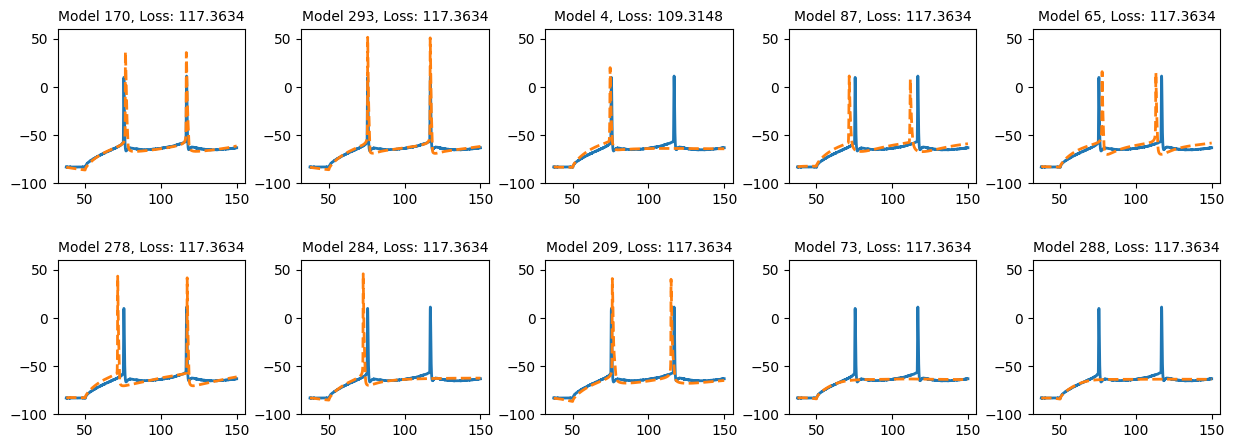

In [ ]:
inds = np.argsort(best_losses)
best_losses = best_losses[inds][:10]
best_preds = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, _, _ = simulate_full_trace(
            model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        best_preds.append(final_preds)
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Multi-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

np.save("multi_2_best_losses.npy", best_losses)
np.save("multi_2_best_preds.npy", best_preds)

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in

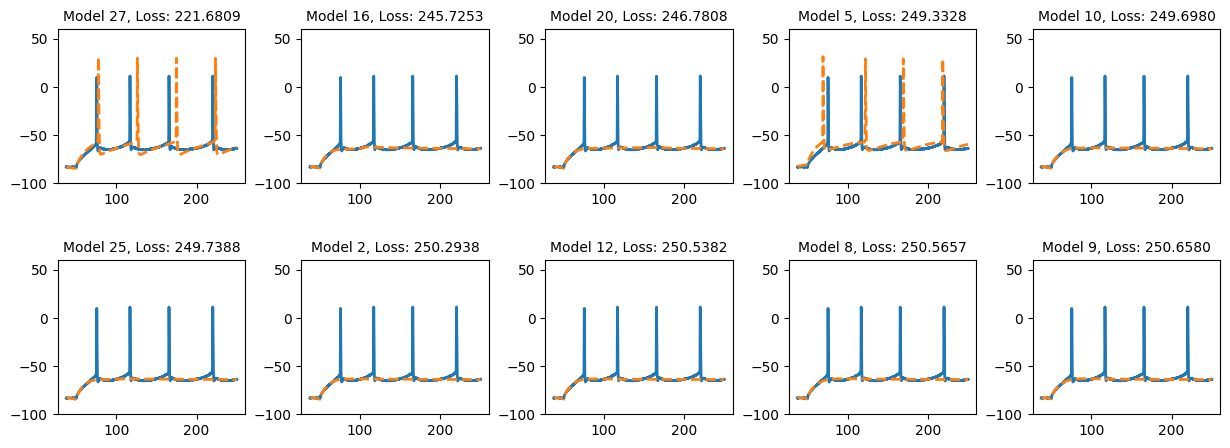

In [ ]:
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, _, _ = simulate_full_trace(
            model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Multi-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

Number of parameters: 25


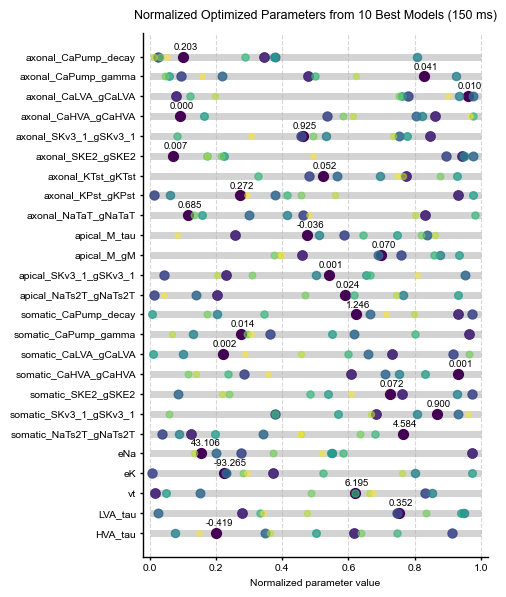

In [ ]:
import matplotlib as mpl

names, lower, upper = get_bounds()

opt_inv_params_list = []
for i in range(10):
    model = jax.tree_util.tree_map(lambda x: x[inds[i]], best_models)
    opt_inv_params = inv_transform_params(model.channel_params_normal)
    opt_inv_params_list.append(opt_inv_params)

param_matrix = np.stack(opt_inv_params_list)

normalized_params = (param_matrix - lower) / (upper - lower)
normalized_params = np.clip(normalized_params, 0, 1)


with mpl.rc_context(fname="../../.matplotlibrc"):
    fig, ax = plt.subplots(figsize=(5, 6))
    indices = np.arange(len(opt_inv_params))

    # Draw the [0, 1] range
    ax.hlines(indices, 0, 1, color='lightgray', linewidth=5, zorder=1)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    colors = plt.cm.Pastel1(np.linspace(0, 1, 10))
    colors = plt.cm.viridis(np.linspace(0.0, 1.0, 10))
    sizes = np.linspace(50, 15, 10)
    alphas = np.linspace(1.0, 0.5, 10)


    # Plot all models
    for j in range(10):
        ax.scatter(normalized_params[j], indices, color=colors[j], s=sizes[j], alpha = alphas[j], label=f'Model {j+1}', zorder=2)

    # Annotate only the best model (j == 0)
    for k in range(len(names)):
        x = normalized_params[0, k]
        y = k
        val = param_matrix[0, k]
        ax.text(x - 0.03, y + 0.5, f"{val:.3f}", fontsize=7, color='k', va='center')


    ax.set_yticks(indices)
    ax.set_yticklabels(names)
    ax.set_xlim(-0.02, 1.02)
    ax.set_xlabel("Normalized parameter value")
    ax.set_title("Normalized Optimized Parameters from 10 Best Models (150 ms)", fontsize = 9, pad = 10)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)

    fig.savefig("optimized_parameters_2.svg", bbox_inches='tight')

    plt.tight_layout()
    plt.show()

Loading the results from the cluster

In [ ]:
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, 200)
)
keys = jax.random.split(jax.random.PRNGKey(0), num=200)

models_for_init = jax.vmap(initialize_model, in_axes=(0, 0, None, None, None))(
    keys, opt_params, u_dimension, W_matrices, epsilon
)

# Load from file
with open("multi_best_models.eqx", "rb") as f:
    loaded_best_models = eqx.tree_deserialise_leaves(f, models_for_init)

loaded_best_losses = np.load("multi_best_losses.npy")

with open("multi_best_models_2.eqx", "rb") as f:
    loaded_best_models_2 = eqx.tree_deserialise_leaves(f, models_for_init)

loaded_best_losses_2 = np.load("multi_best_losses_2.npy")

t_max_long = 250.0

t, v_data_long, i_amp = get_experimental_data(setup, cut, t_max_long)
v_data_long = jnp.asarray(v_data_long[None,])

np.save("results/v_data_long.npy", v_data_long)

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in

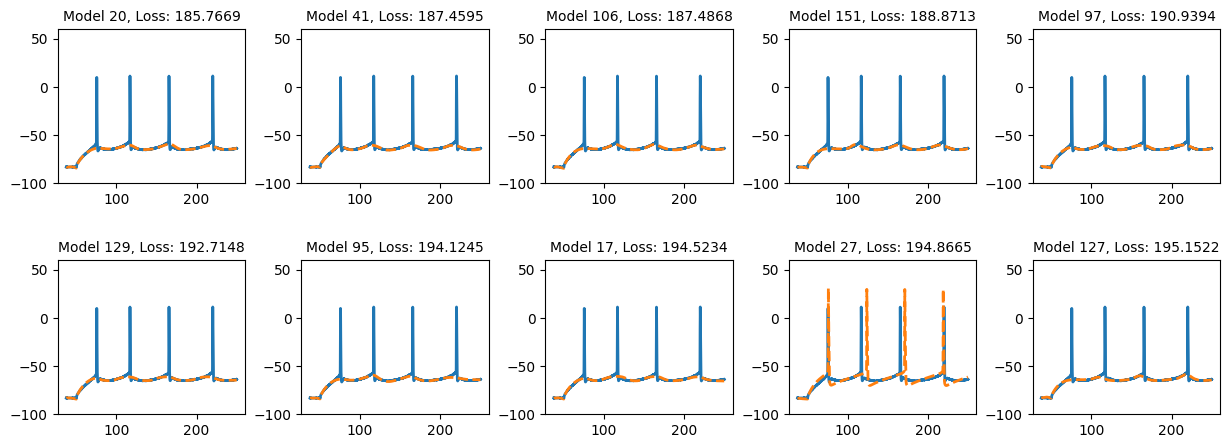

In [ ]:
# added current’s standard deviation was 0.1 and the neural network parameters were clipped to have a norm of maximum 10.0.

inds = np.argsort(loaded_best_losses)
best_losses = loaded_best_losses[inds][:10]
best_preds = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], loaded_best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max_long)
        current = current[cut:]

        cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec_long = setup_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, _, _ = simulate_full_trace(
            model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec_long, u_init, v_data_long.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        best_preds.append(final_preds)
        axs[i,j].plot(time_vec_long, v_data_long[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec_long, final_preds, label="Multi-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {loaded_best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

np.save("multi_4_best_losses.npy", best_losses)
np.save("multi_4_best_preds.npy", best_preds)

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(
/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in

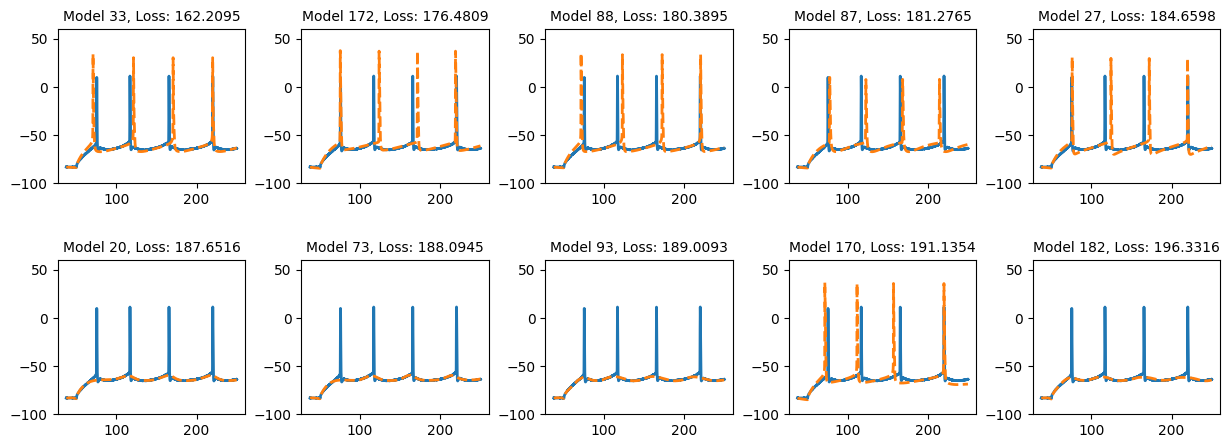

In [ ]:
# added current’s standard deviation was 0.01 and the neural network parameters were clipped to have a norm of maximum 100.0.

inds = np.argsort(loaded_best_losses_2)
best_losses = loaded_best_losses_2[inds][:10]
best_preds = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], loaded_best_models_2)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max_long)
        current = current[cut:]

        cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec_long = setup_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds, final_additional_currents, _, _ = simulate_full_trace(
            model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec_long, u_init, v_data_long.squeeze(), 1.0/100.0, nospike_u_time_constant, spike_u_time_constant, thr
        )
        best_preds.append(final_preds)
        axs[i,j].plot(time_vec_long, v_data_long[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec_long, final_preds, label="Multi-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {loaded_best_losses_2[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

np.save("multi_4_best_losses_new.npy", best_losses)
np.save("multi_4_best_preds_new.npy", best_preds)

Number of parameters: 25


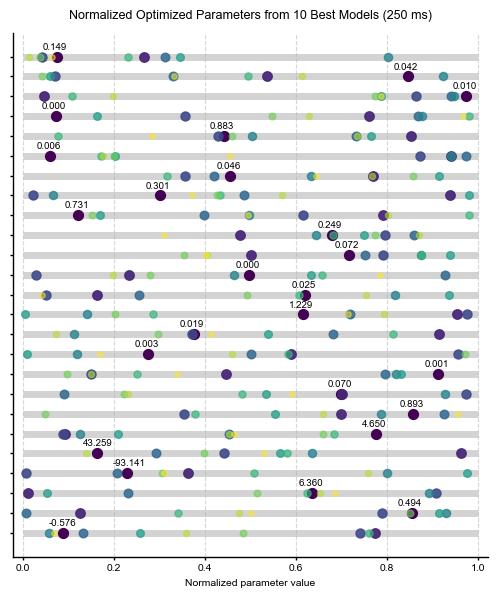

In [ ]:
names, lower, upper = get_bounds()

opt_inv_params_list = []
for i in range(10):
    model = jax.tree_util.tree_map(lambda x: x[inds[i]], loaded_best_models)
    opt_inv_params = inv_transform_params(model.channel_params_normal)
    opt_inv_params_list.append(opt_inv_params)

param_matrix = np.stack(opt_inv_params_list)

normalized_params = (param_matrix - lower) / (upper - lower)
normalized_params = np.clip(normalized_params, 0, 1)


with mpl.rc_context(fname="../../.matplotlibrc"):
    fig, ax = plt.subplots(figsize=(5, 6))
    indices = np.arange(len(opt_inv_params))

    # Draw the [0, 1] range
    ax.hlines(indices, 0, 1, color='lightgray', linewidth=5, zorder=1)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    colors = plt.cm.Pastel1(np.linspace(0, 1, 10))
    colors = plt.cm.viridis(np.linspace(0.0, 1.0, 10))
    sizes = np.linspace(50, 15, 10)
    alphas = np.linspace(1.0, 0.5, 10)


    # Plot all models
    for j in range(10):
        ax.scatter(normalized_params[j], indices, color=colors[j], s=sizes[j], alpha = alphas[j], label=f'Model {j+1}', zorder=2)

    # Annotate only the best model (j == 0)
    for k in range(len(names)):
        x = normalized_params[0, k]
        y = k
        val = param_matrix[0, k]
        ax.text(x - 0.03, y + 0.5, f"{val:.3f}", fontsize=7, color='k', va='center')


    ax.set_yticks(indices)
    ax.set_yticklabels([])
    ax.set_xlim(-0.02, 1.02)
    ax.set_xlabel("Normalized parameter value")
    ax.set_title("Normalized Optimized Parameters from 10 Best Models (250 ms)", fontsize = 9, pad = 10)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)

    fig.savefig("optimized_parameters_4.svg", bbox_inches='tight')

    plt.tight_layout()
    plt.show()